## AirFly Insights: Data Visualization and Analysis of Airline Operations

Dataset link: https://www.kaggle.com/datasets/usdot/flight-delays/data 

Dataset Name: 2015 Flight Delays and Cancellations

### Milestone 1: Data Foundation and Cleaning

### Week 1: Project Initialization and Dataset Setup

• Define goals, KPIs, and workflow

• Load CSVs using pandas

• Explore schema, types, size, and nulls

• Perform sampling and memory optimizations

### Week 2: Preprocessing and Feature Engineering

• Handle nulls in delay and cancellation columns

• Create derived features: Month, Day of Week, Hour, Route

• Format datetime columns

• Save preprocessed data for fast reuse

### Deliverables:

• Cleaned dataset

• Summary of preprocessing logic

• Feature dictionary


### Loading CSVs using Pandas

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')
flights = pd.read_csv('flights.csv') 

In [2]:
print("Airlines:", airlines.shape)
print("Airports:", airports.shape)
print("Flights:", flights.shape)

Airlines: (14, 2)
Airports: (322, 7)
Flights: (5819079, 31)


### Explore schema, types, size, and nulls

In [3]:
print(flights.columns)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')


In [4]:
flights.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [6]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [7]:
flights['DEPARTURE_DELAY'].describe()

count    5.732926e+06
mean     9.370158e+00
std      3.708094e+01
min     -8.200000e+01
25%     -5.000000e+00
50%     -2.000000e+00
75%      7.000000e+00
max      1.988000e+03
Name: DEPARTURE_DELAY, dtype: float64

In [8]:
flights.isnull().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [9]:
flights['AIRLINE'].nunique()

14

In [10]:
flights['AIRLINE'].value_counts()

AIRLINE
WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
NK     117379
F9      90836
HA      76272
VX      61903
Name: count, dtype: int64

In [11]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Memory Optimization

In [12]:
memory_before = flights.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before optimization: {memory_before:.2f} MB")

Memory before optimization: 2484.59 MB


In [13]:
def optimize_dtypes(df):
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in df.select_dtypes(include=['object']).columns:
        unique_ratio = df[col].nunique() / len(df)
        if unique_ratio < 0.5:
            df[col] = df[col].astype('category')
    return df

flights = optimize_dtypes(flights)
memory_after = flights.memory_usage(deep=True).sum() / 1024**2
print(f"Memory after optimization: {memory_after:.2f} MB")

Memory after optimization: 483.34 MB


### Handle nulls in delay and cancellation columns 

In [14]:
flights.isnull().sum().sort_values(ascending=False)


CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
MONTH                        0
ORIGIN_AIRPORT               0
SCHEDULED_DEPARTURE          0
YEAR                         0
SCHEDULED_ARRIVAL            0
DISTANCE                     0
DIVERTED                     0
CANCELLED                    0
dtype: int64

In [15]:
# Fill delay-related NaNs with 0
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
flights[delay_cols] = flights[delay_cols].fillna(0)

In [16]:
# Add 'Not Cancelled' as a valid category first
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].cat.add_categories(['Not Cancelled'])

# Now fill missing values safely
flights['CANCELLATION_REASON'].fillna('Not Cancelled', inplace=True)

In [17]:
flights['CANCELLATION_REASON'].value_counts() 

CANCELLATION_REASON
Not Cancelled    5729195
B                  48851
A                  25262
C                  15749
D                     22
Name: count, dtype: int64

In [18]:
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

In [19]:
flights['MONTH_NAME'] = flights['DATE'].dt.month_name()
flights['DAY_NAME'] = flights['DATE'].dt.day_name()
flights['SEASON'] = flights['MONTH'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})


In [20]:
flights['DATE'].head()

0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: DATE, dtype: datetime64[ns]

In [21]:
flights['DAY_NAME'] = flights['DATE'].dt.day_name()        # Monday, Tuesday, ...
flights['WEEK'] = flights['DATE'].dt.isocalendar().week    # ISO week number

In [22]:
flights.drop(['DAY', 'DAY_OF_WEEK', 'MONTH'], axis=1, inplace=True)

In [23]:
flights.shape

(5819079, 33)

In [24]:
flights.head()

,YEAR,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,MONTH_NAME,DAY_NAME,SEASON,WEEK
0,2015,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
1,2015,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
2,2015,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
3,2015,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1
4,2015,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,...,0.0,0.0,0.0,0.0,0.0,2015-01-01,January,Thursday,Winter,1


In [25]:
flights['ELAPSED_TIME'].isnull().sum()


np.int64(105071)

In [26]:
(flights['ELAPSED_TIME'] == 0).sum()
#checking for zeros (invalid for flights that actually operated)

np.int64(0)

In [27]:
#check for negatives (should NEVER exist):

(flights['ELAPSED_TIME'] < 0).sum()

np.int64(0)

In [28]:
flights[['TAXI_OUT', 'TAXI_IN']].isnull().sum()

TAXI_OUT    89047
TAXI_IN     92513
dtype: int64

In [29]:
#For cancelled or diverted flights: taxi times must be 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)

flights.loc[cancel_mask, ['TAXI_OUT', 'TAXI_IN']] = 0

In [30]:
#For valid flights with missing taxi values: fill with mean
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)

t_out_mean = flights.loc[valid_mask, 'TAXI_OUT'].mean()
t_in_mean = flights.loc[valid_mask, 'TAXI_IN'].mean()


In [31]:
flights[['TAXI_OUT', 'TAXI_IN']].isnull().sum()

TAXI_OUT    0
TAXI_IN     0
dtype: int64

In [32]:
'''Cancelled or diverted flights did not complete a gate-to-gate trip, so
ELAPSED_TIME should be 0
TAXI_OUT, TAXI_IN, AIR_TIME will be 0.'''
# For cancelled or diverted flights → ELAPSED_TIME must be 0
flights.loc[(flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1), 'ELAPSED_TIME'] = 0

# Mask for valid flights where ELAPSED_TIME is missing
mask = (
    flights['ELAPSED_TIME'].isnull() &
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0)
)

# Recalculate ELAPSED_TIME for valid flights
flights.loc[mask, 'ELAPSED_TIME'] = (
    flights.loc[mask, 'TAXI_OUT'] +
    flights.loc[mask, 'AIR_TIME'] +
    flights.loc[mask, 'TAXI_IN']
)



In [33]:
#Check for nulls in AIR_TIME
flights['AIR_TIME'].isnull().sum()

np.int64(105071)

In [34]:
flights.loc[(flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1), 'AIR_TIME'] = 0

In [35]:
import numpy as np

mask = (
    flights['AIR_TIME'].isnull() &
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED'] == 0) &
    flights['ELAPSED_TIME'].notnull()
)

flights.loc[mask, 'AIR_TIME'] = (
    flights.loc[mask, 'ELAPSED_TIME'] -
    (flights.loc[mask, 'TAXI_OUT'].fillna(0) + flights.loc[mask, 'TAXI_IN'].fillna(0))
)

In [36]:
flights['AIR_TIME'].isnull().sum()

np.int64(0)

In [37]:
# No need of TAIL_NUMBER for our analysis, so drop TAIL_NUMBER
flights.drop('TAIL_NUMBER', axis=1, inplace=True)


In [38]:
# Null values count in ARRIVAL_DELAY
flights['ARRIVAL_DELAY'].isnull().sum()

np.int64(105071)

In [39]:
#Cancelled or diverted flights never arrived at destination → delay is 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'ARRIVAL_DELAY'] = 0

In [40]:
#For valid flights, fill missing ARRIVAL_DELAY with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
arrival_delay_median = flights.loc[valid_mask, 'ARRIVAL_DELAY'].median()

flights.loc[valid_mask, 'ARRIVAL_DELAY'] = (
    flights.loc[valid_mask, 'ARRIVAL_DELAY'].fillna(arrival_delay_median)
)

In [41]:
flights['ARRIVAL_DELAY'].isnull().sum()

np.int64(0)

In [42]:
#Checking for null valeues in DEPARTURE_DELAY
flights['DEPARTURE_DELAY'].isnull().sum()

np.int64(86153)

In [43]:
#Cancelled or diverted flights → DEPARTURE_DELAY = 0, Cancelled flights never departed.
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'DEPARTURE_DELAY'] = 0

In [44]:
#Filling missing values for valid flights using median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
departure_delay_median = flights.loc[valid_mask, 'DEPARTURE_DELAY'].median()

flights.loc[valid_mask, 'DEPARTURE_DELAY'] = (
    flights.loc[valid_mask, 'DEPARTURE_DELAY'].fillna(departure_delay_median)
)

In [45]:
flights['DEPARTURE_DELAY'].isnull().sum()

np.int64(0)

In [46]:
flights[['WHEELS_OFF', 'WHEELS_ON']].isnull().sum()

WHEELS_OFF    89047
WHEELS_ON     92513
dtype: int64

In [47]:
#Cancelled or diverted flights → set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, ['WHEELS_OFF', 'WHEELS_ON']] = 0

#Fill Null values for valid flights with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)

wheels_off_median = flights.loc[valid_mask, 'WHEELS_OFF'].median()
wheels_on_median  = flights.loc[valid_mask, 'WHEELS_ON'].median()

In [48]:
flights[['WHEELS_OFF', 'WHEELS_ON']].isnull().sum()

WHEELS_OFF    0
WHEELS_ON     0
dtype: int64

In [49]:
flights['ARRIVAL_TIME'].isnull().sum()
#Checking null values in ARRIVAL_TIME

np.int64(92513)

In [50]:
#Cancelled or diverted flights → Set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'ARRIVAL_TIME'] = 0

In [51]:
#For valid flights Filling missing values with median
valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
arrival_time_median = flights.loc[valid_mask, 'ARRIVAL_TIME'].median()
flights.loc[valid_mask, 'ARRIVAL_TIME'] = (
    flights.loc[valid_mask, 'ARRIVAL_TIME'].fillna(arrival_time_median)
)

In [52]:
flights['ARRIVAL_TIME'].isnull().sum()

np.int64(0)

In [53]:
flights['DEPARTURE_TIME'].isnull().sum()
#Checking null values in DEPARTURE_TIME

np.int64(86153)

In [54]:
#Cancelled / Diverted flights → DEPARTURE_TIME = 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'DEPARTURE_TIME'] = 0

valid_mask = (flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)
departure_time_median = flights.loc[valid_mask, 'DEPARTURE_TIME'].median()

flights.loc[valid_mask, 'DEPARTURE_TIME'] = (
    flights.loc[valid_mask, 'DEPARTURE_TIME'].fillna(departure_time_median)
)

In [55]:
flights['DEPARTURE_TIME'].isnull().sum()

np.int64(0)

In [56]:
#Nan Values count in SCHEDULED_TIME
flights['SCHEDULED_TIME'].isnull().sum()

np.int64(6)

In [57]:
#Cancelled or diverted flights → set to 0
cancel_mask = (flights['CANCELLED'] == 1) | (flights['DIVERTED'] == 1)
flights.loc[cancel_mask, 'SCHEDULED_TIME'] = 0

In [58]:
flights.isnull().sum().sort_values(ascending=False)

YEAR                   0
AIRLINE                0
FLIGHT_NUMBER          0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
WHEELS_OFF             0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
WHEELS_ON              0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
MONTH_NAME             0
DAY_NAME               0
SEASON                 0
WEEK                   0
dtype: int64

### Perfroming Sampling

In [59]:
# The dataset is large, so we create a smaller version for smoother analysis.
# Sampling is done in a stratified way so each airline keeps its proportion.

# Choose the fraction of data you want to keep (2% is usually a good balance)
sample_fraction = 0.02  

# Perform stratified sampling grouped by airline
sample = (
    flights
    .groupby('AIRLINE')        # keep distribution across airlines
    .sample(frac=sample_fraction, random_state=42)
)

# Print the size of the sampled dataset
print("Sample shape:", sample.shape)

# Save the sampled data for quick loading later
sample.to_csv("flights_sample.csv", index=False)

print("Sampling complete. File saved as flights_sample.csv")

Sample shape: (116382, 32)
Sampling complete. File saved as flights_sample.csv


In [60]:
flights.columns

Index(['YEAR', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'MONTH_NAME', 'DAY_NAME', 'SEASON', 'WEEK'],
      dtype='object')

### Feature Engineering

In [61]:
# Convert to string to avoid Categorical + string error
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].astype(str)
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].astype(str)

# Now create the ROUTE column
flights['ROUTE'] = flights['ORIGIN_AIRPORT'] + " → " + flights['DESTINATION_AIRPORT']

In [62]:
# Extract hour from HHMM format
flights['DEPARTURE_HOUR'] = flights['DEPARTURE_TIME'] // 100
flights['ARRIVAL_HOUR'] = flights['ARRIVAL_TIME'] // 100

In [63]:
# Create IS_WEEKEND feature
flights['IS_WEEKEND'] = flights['DAY_NAME'].isin(['Saturday', 'Sunday']).astype(int)

In [64]:
# Create DELAY_CATEGORY feature
def categorize_delay(x):
    if x <= 0:
        return "On Time"
    elif x <= 15:
        return "Minor Delay"
    elif x <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

flights['DELAY_CATEGORY'] = flights['ARRIVAL_DELAY'].apply(categorize_delay)


In [65]:
# sum of all delay columns
delay_cols = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

flights['TOTAL_DELAY'] = flights[delay_cols].sum(axis=1)


In [66]:
# Distance bucketization (useful for correlation heatmaps)
def bucket_distance(d):
    if d < 300:
        return "Short Haul"
    elif d < 1500:
        return "Medium Haul"
    else:
        return "Long Haul"

flights['DISTANCE_BUCKET'] = flights['DISTANCE'].apply(bucket_distance)


In [67]:
# is flight departing night time 
flights['IS_RED_EYE'] = flights['DEPARTURE_HOUR'].between(22, 23) | flights['DEPARTURE_HOUR'].between(0, 4)
flights['IS_RED_EYE'] = flights['IS_RED_EYE'].astype(int)

In [68]:
# Avoid division by zero (AIR_TIME already cleaned)
flights['FLIGHT_SPEED'] = flights['DISTANCE'] / (flights['AIR_TIME'] / 60).replace(0, np.nan)
flights['FLIGHT_SPEED'] = flights['FLIGHT_SPEED'].fillna(0)

In [69]:
flights.columns

Index(['YEAR', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED',
       'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'DATE', 'MONTH_NAME', 'DAY_NAME', 'SEASON', 'WEEK',
       'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR', 'IS_WEEKEND',
       'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET', 'IS_RED_EYE',
       'FLIGHT_SPEED'],
      dtype='object')

In [70]:
flights.head()

,YEAR,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,WEEK,ROUTE,DEPARTURE_HOUR,ARRIVAL_HOUR,IS_WEEKEND,DELAY_CATEGORY,TOTAL_DELAY,DISTANCE_BUCKET,IS_RED_EYE,FLIGHT_SPEED
0,2015,AS,98,ANC,SEA,5,2354.0,-11.0,21.0,15.0,...,1,ANC → SEA,23.0,4.0,0,On Time,0.0,Medium Haul,1,514.082825
1,2015,AA,2336,LAX,PBI,10,2.0,-8.0,12.0,14.0,...,1,LAX → PBI,0.0,7.0,0,On Time,0.0,Long Haul,1,531.558960
2,2015,US,840,SFO,CLT,20,18.0,-2.0,16.0,34.0,...,1,SFO → CLT,0.0,8.0,0,Minor Delay,0.0,Long Haul,1,517.894714
3,2015,AA,258,LAX,MIA,20,15.0,-5.0,15.0,30.0,...,1,LAX → MIA,0.0,7.0,0,On Time,0.0,Long Haul,1,544.651123
4,2015,AS,135,SEA,ANC,25,24.0,-1.0,11.0,35.0,...,1,SEA → ANC,0.0,2.0,0,On Time,0.0,Medium Haul,1,436.582916


In [71]:
# Columns you want to remove
columns_to_drop = [
    'FLIGHT_NUMBER',
    'WHEELS_OFF',
    'WHEELS_ON',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL'
]
flights.drop(columns=columns_to_drop, inplace=True)

print("Dropped columns:", columns_to_drop)
print("Remaining columns:", flights.columns)


Dropped columns: ['FLIGHT_NUMBER', 'WHEELS_OFF', 'WHEELS_ON', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL']
Remaining columns: Index(['YEAR', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE', 'MONTH_NAME',
       'DAY_NAME', 'SEASON', 'WEEK', 'ROUTE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR',
       'IS_WEEKEND', 'DELAY_CATEGORY', 'TOTAL_DELAY', 'DISTANCE_BUCKET',
       'IS_RED_EYE', 'FLIGHT_SPEED'],
      dtype='object')


### Milestone 2: Visual Exploration and Delay Trends 

### Week 3: Univariate and Bivariate Visual Analysis 

• Top airlines, routes, and busiest months 

• Flight distribution by day, time, and airport 

• Plot bar charts, histograms, boxplots, and line plots 

### Week 4: Delay Analysis – Airline and Weather 

• Compare delay causes by airline 

• Explore carrier delays, weather delays, NAS delays 

• Visualize delays by time of day and airport 


### Deliverables:

• Set of visualizations (minimum 8) 

• Observations on peak delays and top delay-prone carriers

### Let's start with EDA

In [72]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 36 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int16         
 1   AIRLINE              category      
 2   ORIGIN_AIRPORT       object        
 3   DESTINATION_AIRPORT  object        
 4   DEPARTURE_TIME       float32       
 5   DEPARTURE_DELAY      float32       
 6   TAXI_OUT             float32       
 7   SCHEDULED_TIME       float32       
 8   ELAPSED_TIME         float32       
 9   AIR_TIME             float32       
 10  DISTANCE             int16         
 11  TAXI_IN              float32       
 12  ARRIVAL_TIME         float32       
 13  ARRIVAL_DELAY        float32       
 14  DIVERTED             int8          
 15  CANCELLED            int8          
 16  CANCELLATION_REASON  category      
 17  AIR_SYSTEM_DELAY     float32       
 18  SECURITY_DELAY       float32       
 19  AIRLINE_DELAY        

In [73]:
flights.describe()

,YEAR,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,TAXI_IN,ARRIVAL_TIME,...,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DATE,WEEK,DEPARTURE_HOUR,ARRIVAL_HOUR,IS_WEEKEND,TOTAL_DELAY,IS_RED_EYE,FLIGHT_SPEED
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,...,5.819079e+06,5.819079e+06,5819079,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06
mean,2015.0,1.310959e+03,9.127011e+00,1.577541e+01,1.393319e+02,1.345324e+02,1.114620e+02,8.223565e+02,7.294922e+00,1.449716e+03,...,4.289670e+00,5.327704e-01,2015-07-01 21:46:24.656542976,26.997184,1.281322e+01,1.420688e+01,2.609191e-01,1.076663e+01,5.891998e-02,4.013437e+02
min,2015.0,0.000000e+00,-8.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,2015-01-01 00:00:00,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,9.060000e+02,-5.000000e+00,1.100000e+01,8.500000e+01,8.100000e+01,5.900000e+01,3.730000e+02,4.000000e+00,1.044000e+03,...,0.000000e+00,0.000000e+00,2015-04-04 00:00:00,14.0,9.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.631035e+02
50%,2015.0,1.320000e+03,-1.000000e+00,1.400000e+01,1.210000e+02,1.170000e+02,9.300000e+01,6.470000e+02,6.000000e+00,1.502000e+03,...,0.000000e+00,0.000000e+00,2015-07-02 00:00:00,27.0,1.300000e+01,1.500000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.139062e+02
75%,2015.0,1.736000e+03,7.000000e+00,1.900000e+01,1.720000e+02,1.670000e+02,1.430000e+02,1.062000e+03,9.000000e+00,1.912000e+03,...,0.000000e+00,0.000000e+00,2015-09-29 00:00:00,40.0,1.700000e+01,1.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,4.550000e+02
max,2015.0,2.400000e+03,1.988000e+03,2.250000e+02,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.480000e+02,2.400000e+03,...,1.331000e+03,1.211000e+03,2015-12-31 00:00:00,53.0,2.400000e+01,2.400000e+01,1.000000e+00,1.971000e+03,1.000000e+00,7.878688e+02
std,0.0,5.230539e+02,3.657611e+01,9.058117e+00,7.698544e+01,7.576709e+01,7.315421e+01,6.077843e+02,5.655182e+00,5.570446e+02,...,2.057421e+01,8.807466e+00,NaN,14.8697,5.226896e+00,5.557400e+00,4.391359e-01,3.567634e+01,2.354749e-01,8.773317e+01


In [74]:
flights.describe(include='object')

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,MONTH_NAME,DAY_NAME,SEASON,ROUTE,DELAY_CATEGORY,DISTANCE_BUCKET
count,5819079,5819079,5819079,5819079,5819079,5819079,5819079,5819079
unique,628,629,12,7,4,8609,4,3
top,ATL,ATL,July,Thursday,Summer,SFO → LAX,On Time,Medium Haul
freq,346836,346904,520718,872521,1535151,13744,3732183,4040667


In [75]:
flights.isnull().sum()

YEAR                   0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
TAXI_IN                0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
DATE                   0
MONTH_NAME             0
DAY_NAME               0
SEASON                 0
WEEK                   0
ROUTE                  0
DEPARTURE_HOUR         0
ARRIVAL_HOUR           0
IS_WEEKEND             0
DELAY_CATEGORY         0
TOTAL_DELAY            0
DISTANCE_BUCKET        0
IS_RED_EYE             0
FLIGHT_SPEED           0
dtype: int64

### UNIVARIATE ANALYSIS

In [77]:
import matplotlib.pyplot as plt

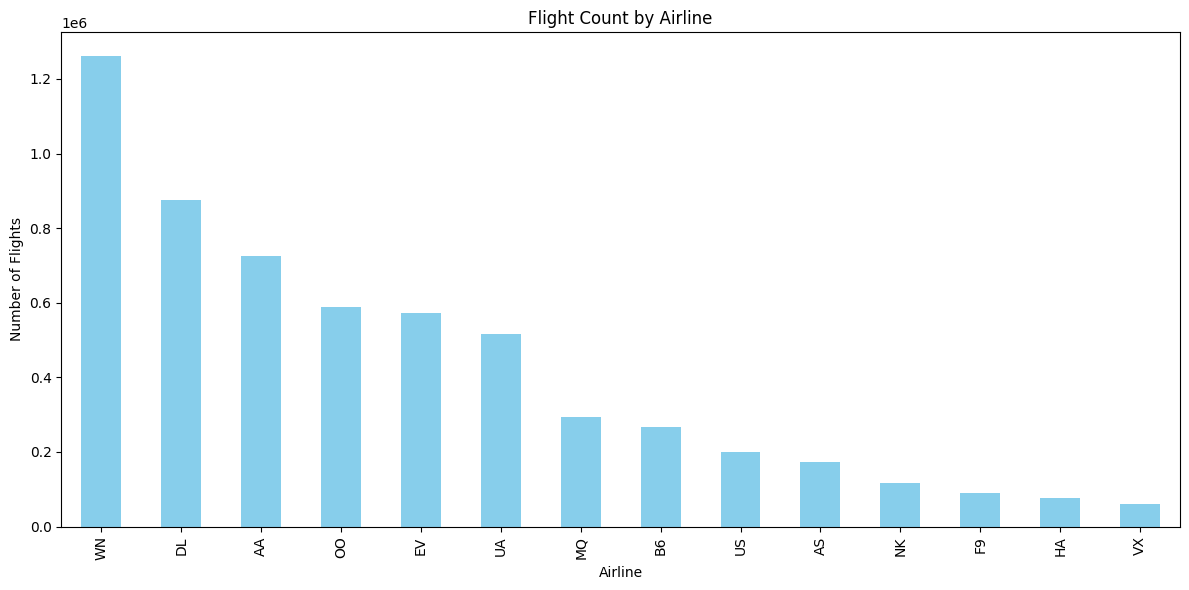

In [78]:
# 1. Top Airlines (Bar Chart)
plt.figure(figsize=(12,6))
flights['AIRLINE'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Flight Count by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

In [80]:
'''These numbers are fractions, not counts.
0.2 = 20% of total flights
0.4 = 40% of total flights
0.6 = 60% of total flights'''

'These numbers are fractions, not counts.\n0.2 = 20% of total flights\n0.4 = 40% of total flights\n0.6 = 60% of total flights'

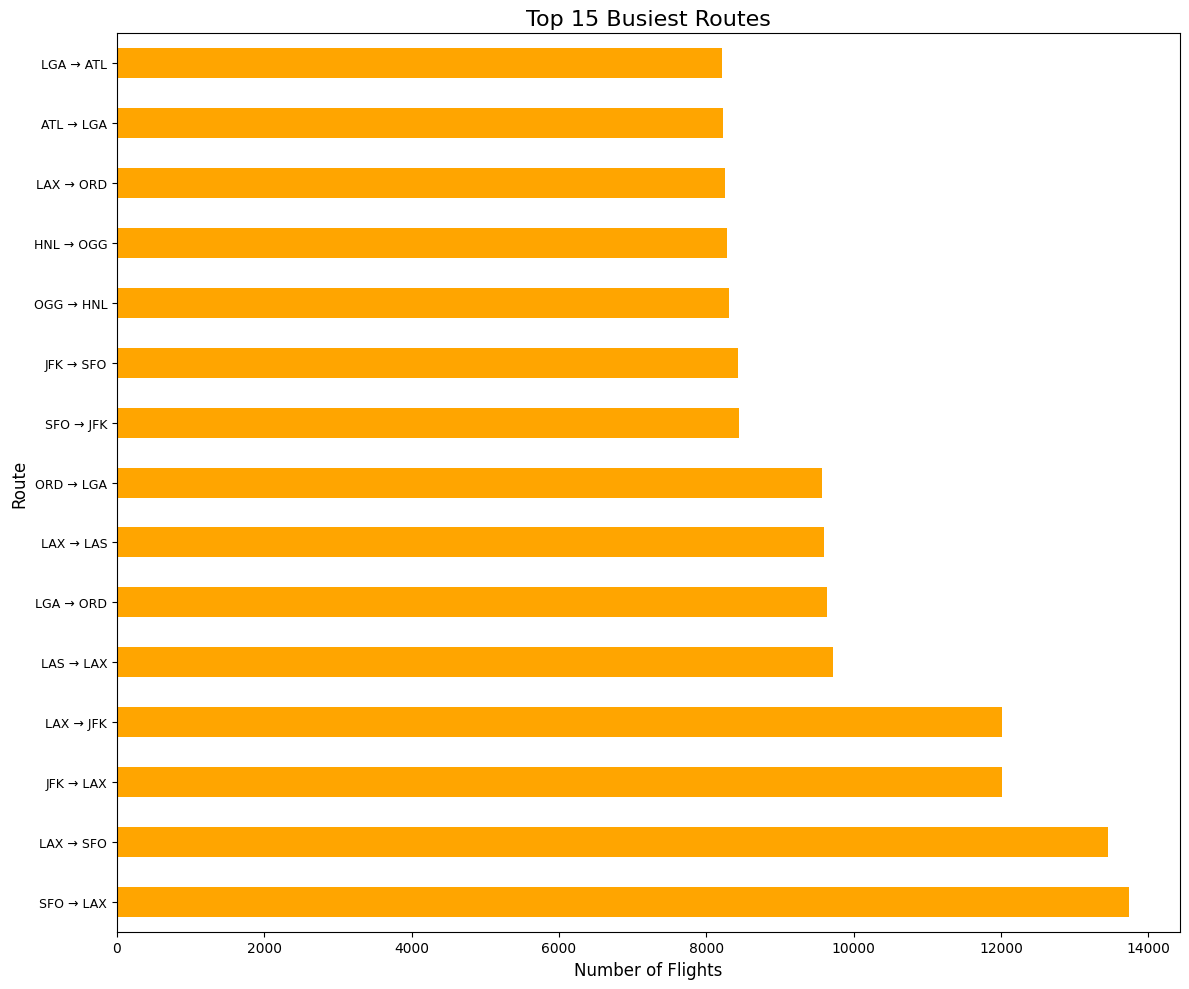

In [92]:
#2. Top Routes (Bar Chart)
top_routes = flights['ROUTE'].value_counts().head(15)

plt.figure(figsize=(12,10))  # make it taller

top_routes.plot(
    kind='barh',
    color='orange'
)

plt.title('Top 15 Busiest Routes', fontsize=16)
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Route', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=9)  # smaller tick labels to avoid overlap

plt.tight_layout()
plt.show()



In [93]:
print(airlines)

   IATA_CODE                       AIRLINE
0         UA         United Air Lines Inc.
1         AA        American Airlines Inc.
2         US               US Airways Inc.
3         F9        Frontier Airlines Inc.
4         B6               JetBlue Airways
5         OO         Skywest Airlines Inc.
6         AS          Alaska Airlines Inc.
7         NK              Spirit Air Lines
8         WN        Southwest Airlines Co.
9         DL          Delta Air Lines Inc.
10        EV   Atlantic Southeast Airlines
11        HA        Hawaiian Airlines Inc.
12        MQ  American Eagle Airlines Inc.
13        VX                Virgin America


In [95]:
print(airports)

    IATA_CODE                              AIRPORT  \
0         ABE  Lehigh Valley International Airport   
1         ABI             Abilene Regional Airport   
2         ABQ    Albuquerque International Sunport   
3         ABR            Aberdeen Regional Airport   
4         ABY   Southwest Georgia Regional Airport   
..        ...                                  ...   
317       WRG                     Wrangell Airport   
318       WYS               Westerly State Airport   
319       XNA  Northwest Arkansas Regional Airport   
320       YAK                      Yakutat Airport   
321       YUM           Yuma International Airport   

                               CITY STATE COUNTRY  LATITUDE  LONGITUDE  
0                         Allentown    PA     USA  40.65236  -75.44040  
1                           Abilene    TX     USA  32.41132  -99.68190  
2                       Albuquerque    NM     USA  35.04022 -106.60919  
3                          Aberdeen    SD     USA  45.44906

In [97]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


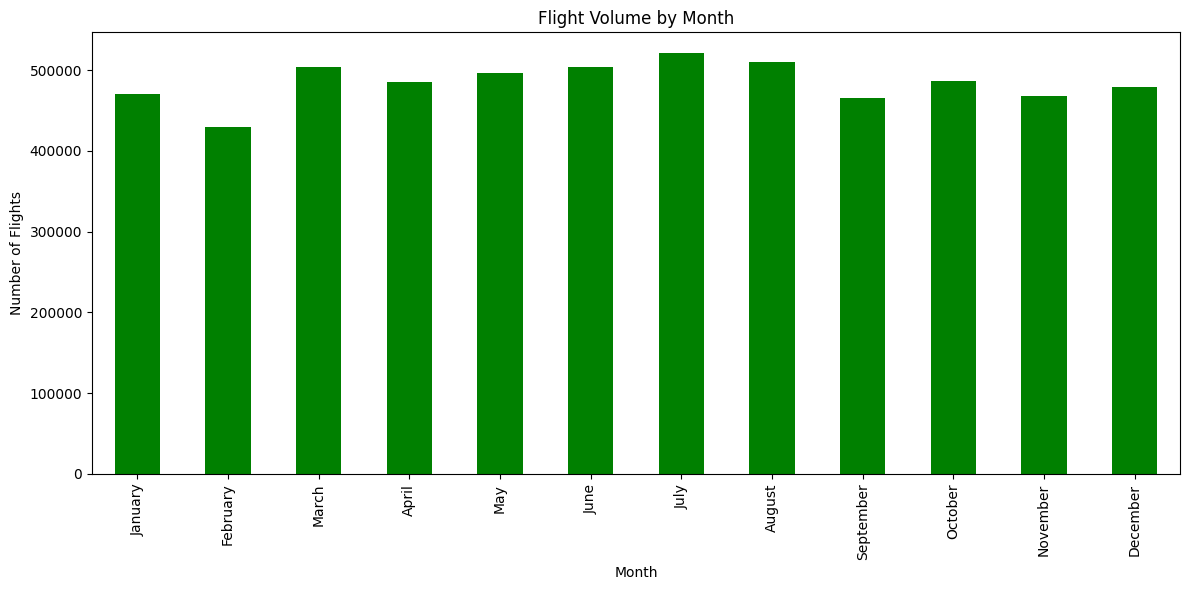

In [82]:
#3. Busiest Months (Bar Chart)
plt.figure(figsize=(12,6))
flights['MONTH_NAME'].value_counts().loc[
    ['January','February','March','April','May','June','July','August','September','October','November','December']
].plot(kind='bar', color='green')

plt.title('Flight Volume by Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

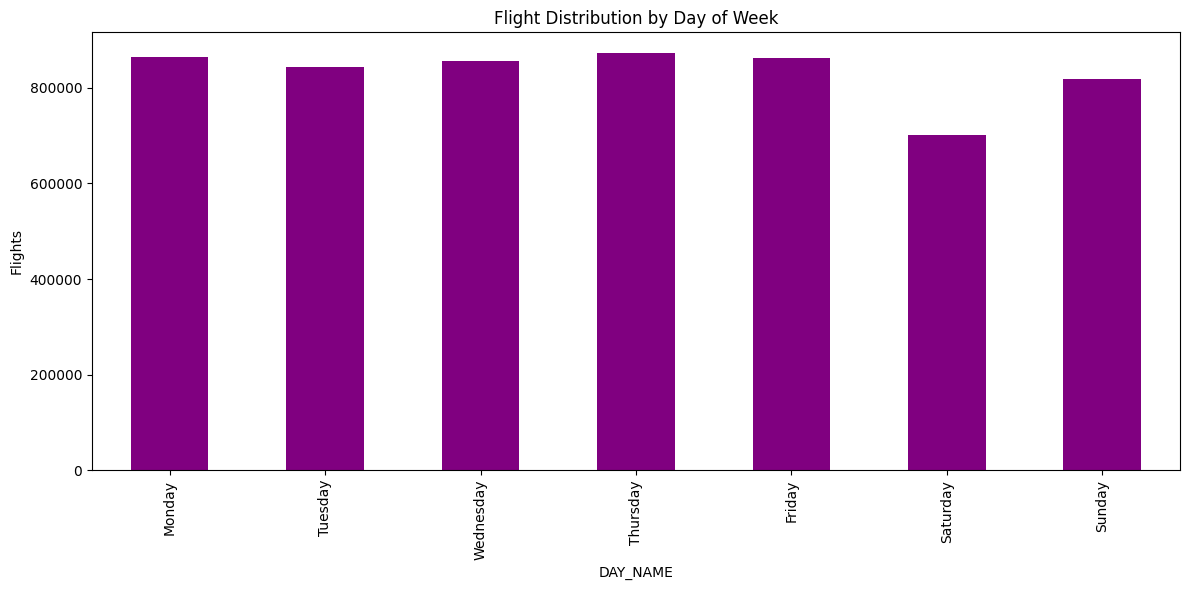

In [83]:
#4.Distribution by Day of Week
plt.figure(figsize=(12,6))
flights['DAY_NAME'].value_counts().loc[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
].plot(kind='bar', color='purple')

plt.title('Flight Distribution by Day of Week')
plt.ylabel('Flights')
plt.tight_layout()
plt.show()

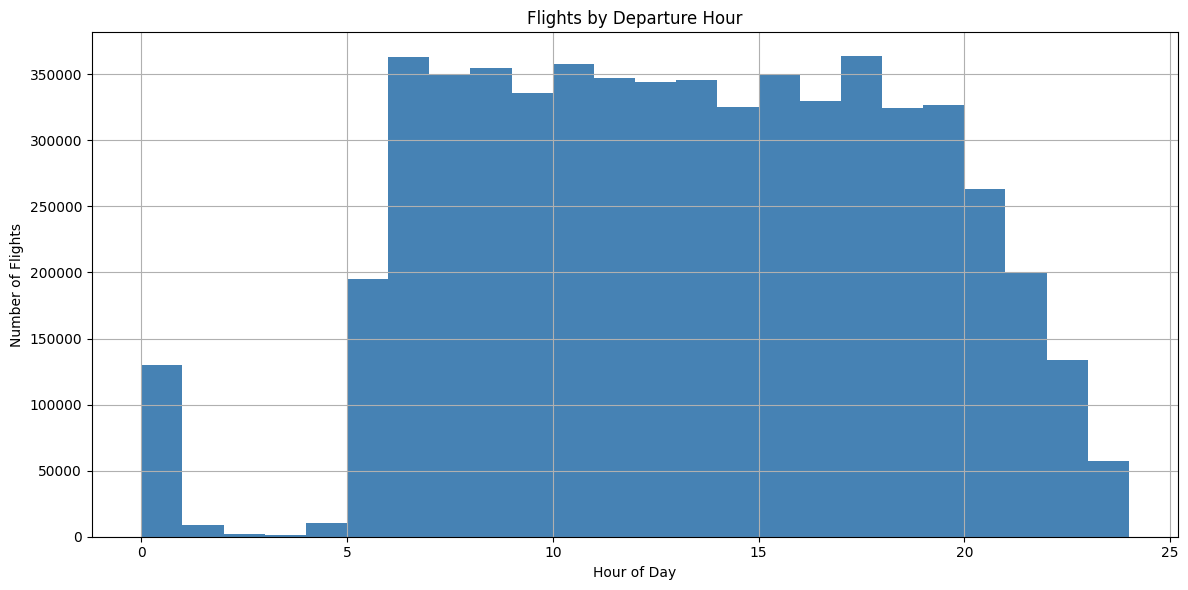

In [84]:
#5. Departure Hour Distribution (Histogram)
plt.figure(figsize=(12,6))
flights['DEPARTURE_HOUR'].hist(bins=24, color='steelblue')
plt.title('Flights by Departure Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

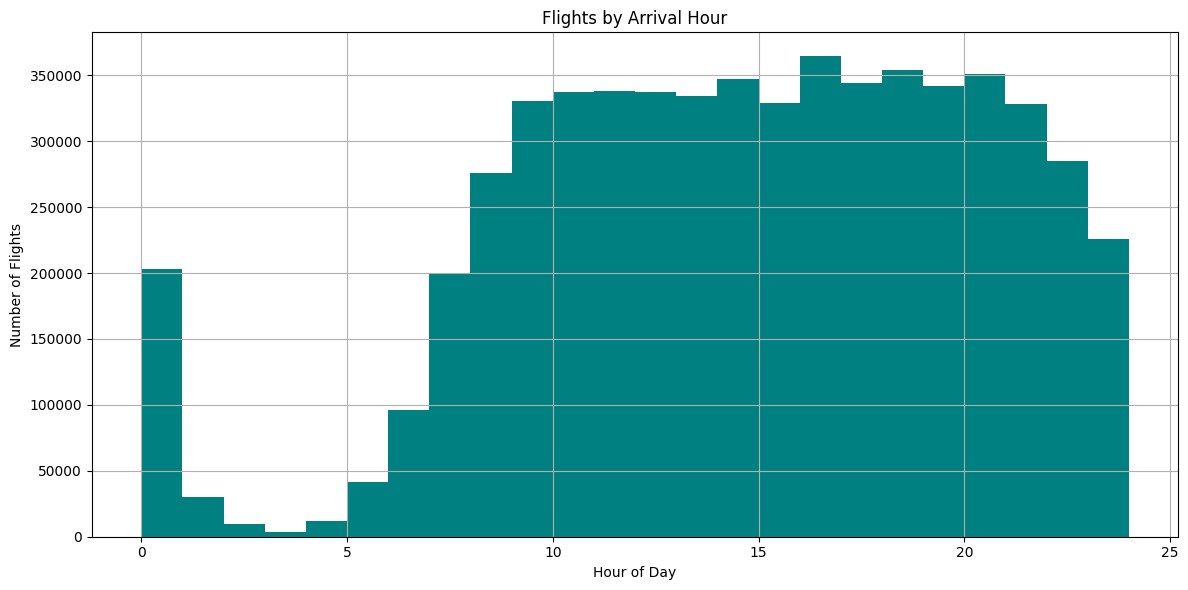

In [85]:
#6. Arrival Hour Distribution (Histogram)
plt.figure(figsize=(12,6))
flights['ARRIVAL_HOUR'].hist(bins=24, color='teal')
plt.title('Flights by Arrival Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

### BIVARIATE ANALYSIS

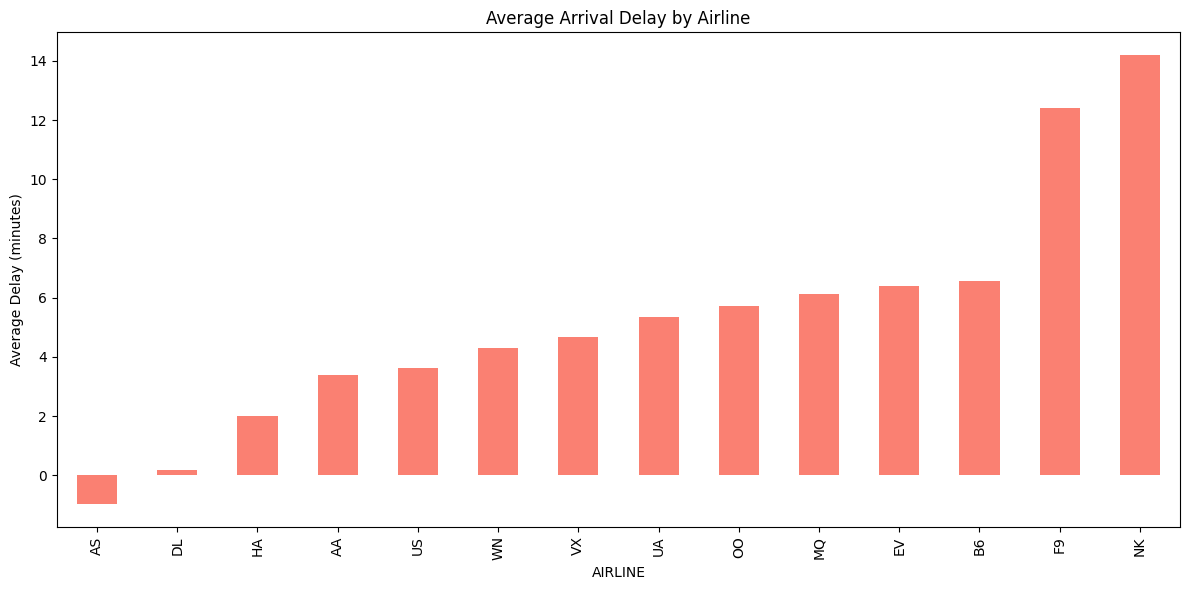

In [86]:
#7. Airline vs Average Arrival Delay (Bar Plot)
plt.figure(figsize=(12,6))
flights.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values().plot(kind='bar', color='salmon')
plt.title('Average Arrival Delay by Airline')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

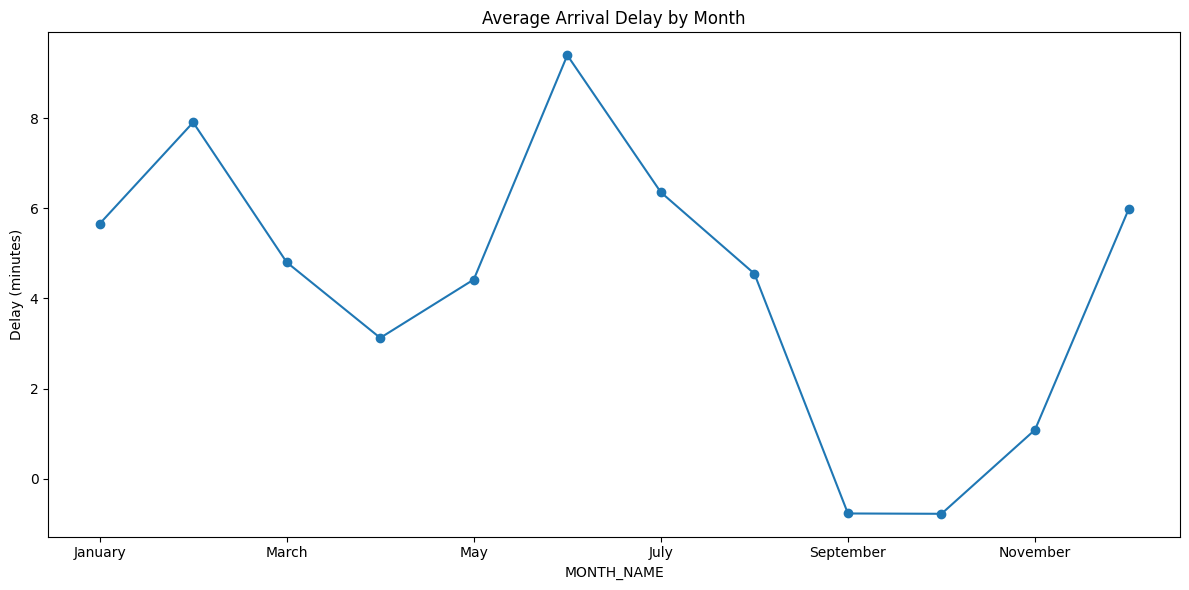

In [87]:
#8. Month vs Average Delay (Line Plot)
order = ['January','February','March','April','May','June','July','August','September','October','November','December']

plt.figure(figsize=(12,6))
flights.groupby('MONTH_NAME')['ARRIVAL_DELAY'].mean().loc[order].plot(kind='line', marker='o')
plt.title('Average Arrival Delay by Month')
plt.ylabel('Delay (minutes)')
plt.tight_layout()
plt.show()

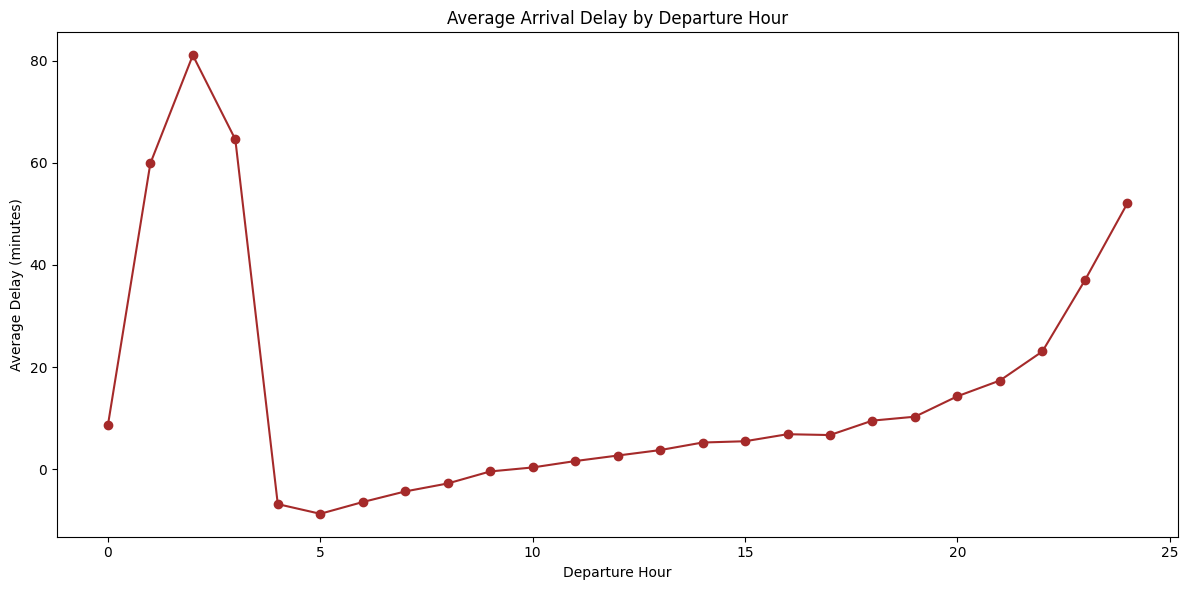

In [88]:
#9. Departure Hour vs Average Delay (Line Plot)
plt.figure(figsize=(12,6))
flights.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean().plot(kind='line', marker='o', color='brown')
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Delay (minutes)')
plt.tight_layout()
plt.show()

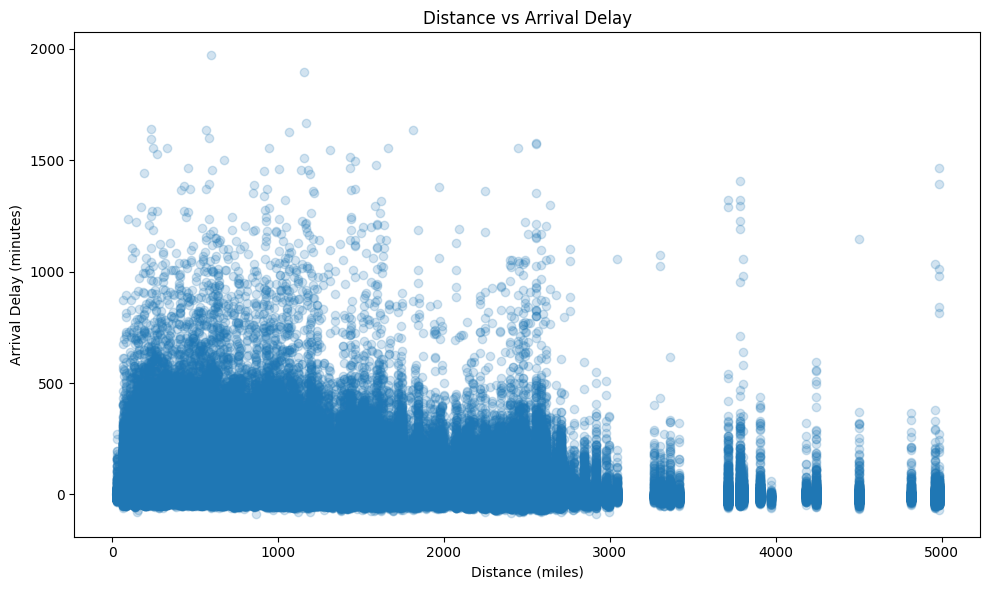

In [89]:
#10. Distance vs Arrival Delay (Scatter Plot)
plt.figure(figsize=(10,6))
plt.scatter(flights['DISTANCE'], flights['ARRIVAL_DELAY'], alpha=0.2)
plt.title('Distance vs Arrival Delay')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

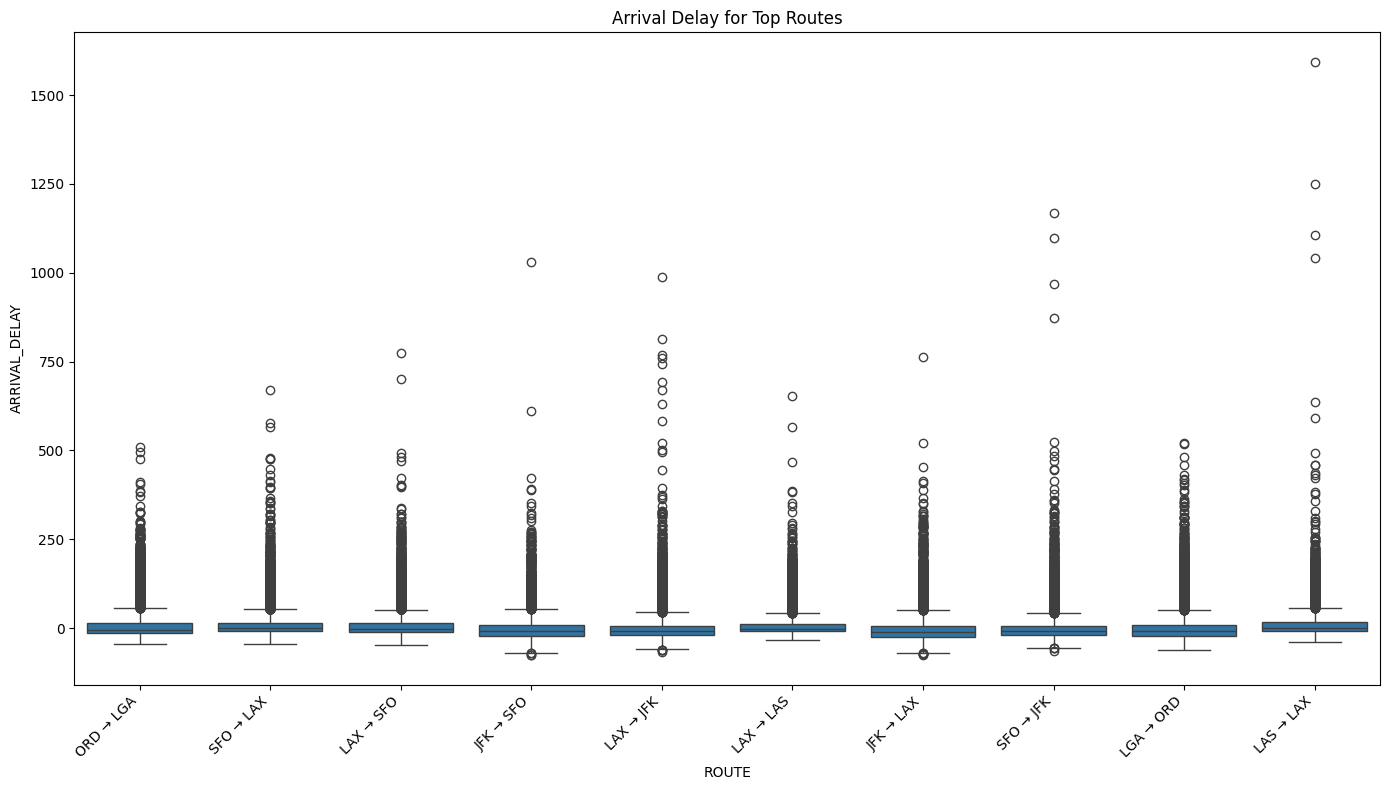

In [91]:
#11. Route vs Delay (Boxplot for major routes only)
import seaborn as sns

major_routes = flights['ROUTE'].value_counts().head(10).index
plt.figure(figsize=(14,8))
sns.boxplot(x='ROUTE', y='ARRIVAL_DELAY', data=flights[flights['ROUTE'].isin(major_routes)])
plt.xticks(rotation=45, ha='right')
plt.title('Arrival Delay for Top Routes')
plt.tight_layout()
plt.show()